In [1]:
from parameters import load_json
from simulation import run_readout_pair


def test_example_readout_runs():
    device, pulse, simulation = load_json("device_parameter.json")
    result = run_readout_pair(device, pulse, simulation)
    print(result)

    assert result.ground.resonator_population.shape == simulation.tsave.shape
    assert result.excited.resonator_population.shape == simulation.tsave.shape
    assert result.snr.shape == simulation.tsave.shape
    assert result.assignment_error.shape == simulation.tsave.shape
    assert result.ground.leakage[-1] >= -1e-8
    assert result.excited.leakage[-1] >= -1e-8

    return device, pulse, simulation, result

In [ ]:
device, pulse, simulation, result = test_example_readout_runs()

/Users/qumacminim4-c/CR_gate_and_Fluxonium/Fluxonium_sims/hamiltonian.py:28: UserWarning: A sparse qarray has been converted to dense layout due to element-wise addition with a dense qarray.
  "h_static": h_resonator + h_fluxonium + params.g * drive_op @ n,


In [ ]:
print(result.infos)

AttributeError: 'ReadoutPairResult' object has no attribute 'infos'

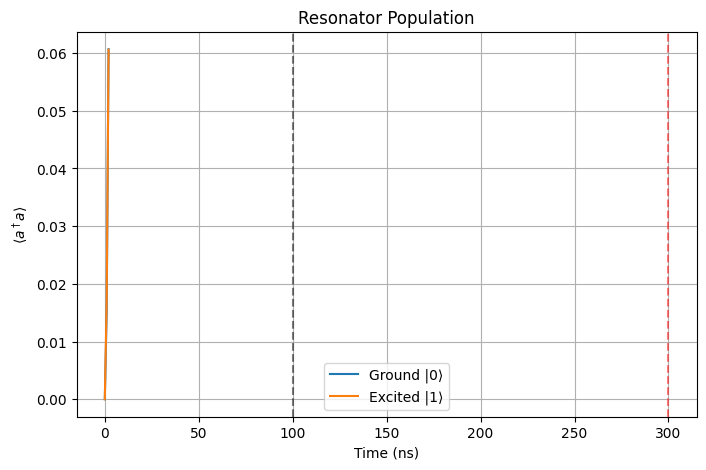

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t = np.asarray(simulation.tsave)
n_g = np.asarray(result.ground.resonator_population)
n_e = np.asarray(result.excited.resonator_population)

plt.figure(figsize=(8, 5))
plt.plot(t, n_g, label="Ground |0⟩")
plt.plot(t, n_e, label="Excited |1⟩")

plt.axvline(100, color="k", linestyle="--", alpha=0.5)
plt.axvline(300, color="r", linestyle="--", alpha=0.5)

plt.xlabel("Time (ns)")
plt.ylabel(r"$\langle a^\dagger a\rangle$")
plt.title("Resonator Population")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from pathlib import Path

p = Path("device_parameter.json").resolve()
print(p)

/Users/qumacminim4-c/CR_gate_and_Fluxonium/Fluxonium_sims/device_parameter.json


In [ ]:
from pathlib import Path

p = Path("/Users/qumacminim4-c/CR_gate_and_Fluxonium/Fluxonium_sims/device_parameter.json")

print(p.exists())
print(p.stat().st_size)

True
7963


In [ ]:
test_example_readout_runs()

print("Test passed!")

|█▋        |  16.8% ◆ elapsed 26m39s ◆ remaining 02h25m55s

In [ ]:
from __future__ import annotations

import jax.numpy as jnp
import numpy as np
import dynamiqs as dq

from parameters import DeviceParameters, PulseParameters


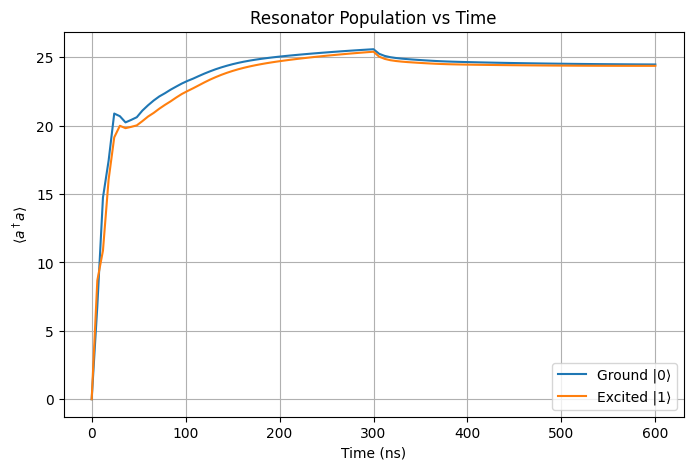

In [ ]:
import matplotlib.pyplot as plt

# Time axis
t = simulation.tsave

# Ground-state trajectory
n_g = result.ground.resonator_population

# Excited-state trajectory
n_e = result.excited.resonator_population

plt.figure(figsize=(8, 5))

plt.plot(t, n_g, label="Ground |0⟩")
plt.plot(t, n_e, label="Excited |1⟩")

plt.xlabel("Time (ns)")
plt.ylabel(r"$\langle a^\dagger a\rangle$")
plt.title("Resonator Population vs Time")
plt.grid(True)
plt.legend()

plt.show()